**Project Title :**

Flood Risk Prediction and Assessment


**Problem Statement :**

Floods are one of the most devastating natural diasters,causing significant loss of life,property damage, and displacement of communities.


**Description :**

Floodrisk evaluation is a comprehensive flood risk assessment project that aims to identify,analyze,and mitigate flood risks in vulnerable areas.

In [1]:
#import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Load the dataset
data = pd.read_csv("/content/flood_risk_dataset.csv")

In [3]:
#Display the datas
print(data.head)

<bound method NDFrame.head of        Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
0     18.861663  78.835584     218.999493         34.144337     43.912963   
1     35.570715  77.654451      55.353599         28.778774     27.585422   
2     29.227824  73.108463     103.991908         43.934956     30.108738   
3     25.361096  85.610733     198.984191         21.569354     34.453690   
4     12.524541  81.822101     144.626803         32.635692     36.292267   
...         ...        ...            ...               ...           ...   
9995  32.872024  93.434120     285.682635         37.621017     69.795616   
9996  34.027756  69.357605     224.347263         37.935808     38.095486   
9997  35.454530  76.807256       5.836759         23.087083     79.919607   
9998  19.527152  80.856280     120.301453         28.029593     61.680873   
9999  14.297072  72.995680      77.219394         29.622711     88.936537   

      River Discharge (m³/s)  Water Level (m)

In [4]:
#Basic Info
print("Dataset Info::\n")
print(data.info())

Dataset Info::

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int64(3)

In [5]:
#Describe the dataset
print("\n Dataset Describe::\n")
print(data.describe())


 Dataset Describe::

           Latitude     Longitude  Rainfall (mm)  Temperature (°C)  \
count  10000.000000  10000.000000   10000.000000      10000.000000   
mean      22.330627     82.631366     150.015118         29.961401   
std        8.341274      8.389542      86.032127          8.669838   
min        8.000337     68.004575       0.014437         15.000166   
25%       15.143537     75.364428      76.124373         22.405717   
50%       22.283330     82.671007     150.620428         30.000907   
75%       29.460184     89.937897     223.402156         37.413488   
max       36.991813     96.997820     299.970293         44.993681   

       Humidity (%)  River Discharge (m³/s)  Water Level (m)  Elevation (m)  \
count  10000.000000            10000.000000     10000.000000   10000.000000   
mean      59.749104             2515.722946         5.017881    4417.138177   
std       23.142734             1441.706442         2.876579    2530.245421   
min       20.001339            

In [7]:
#Chech missing value
print("\n Missing Values Count::\n")
print(data.isnull().sum())


 Missing Values Count::

Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64



Flood Occurrence distribution::

Flood Occurred
1    0.5057
0    0.4943
Name: proportion, dtype: float64

Histogram of numerical features::



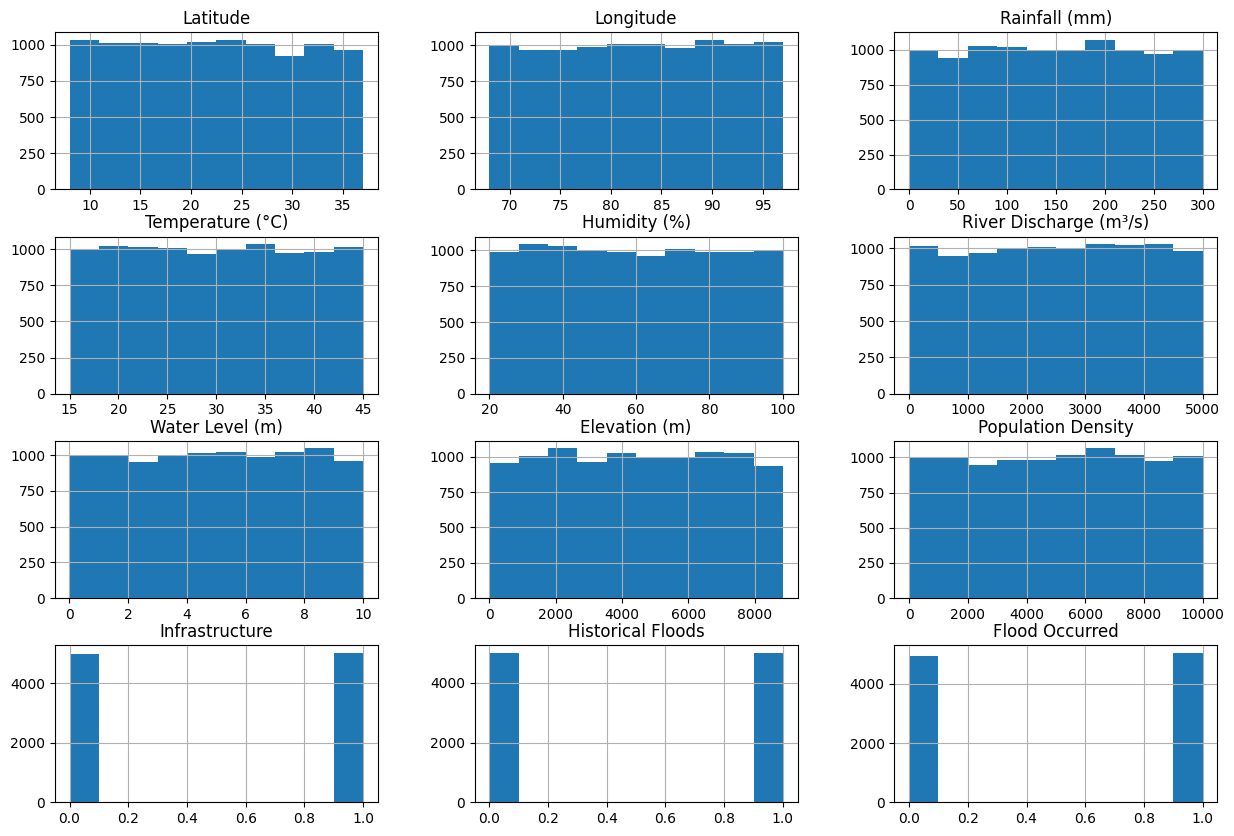

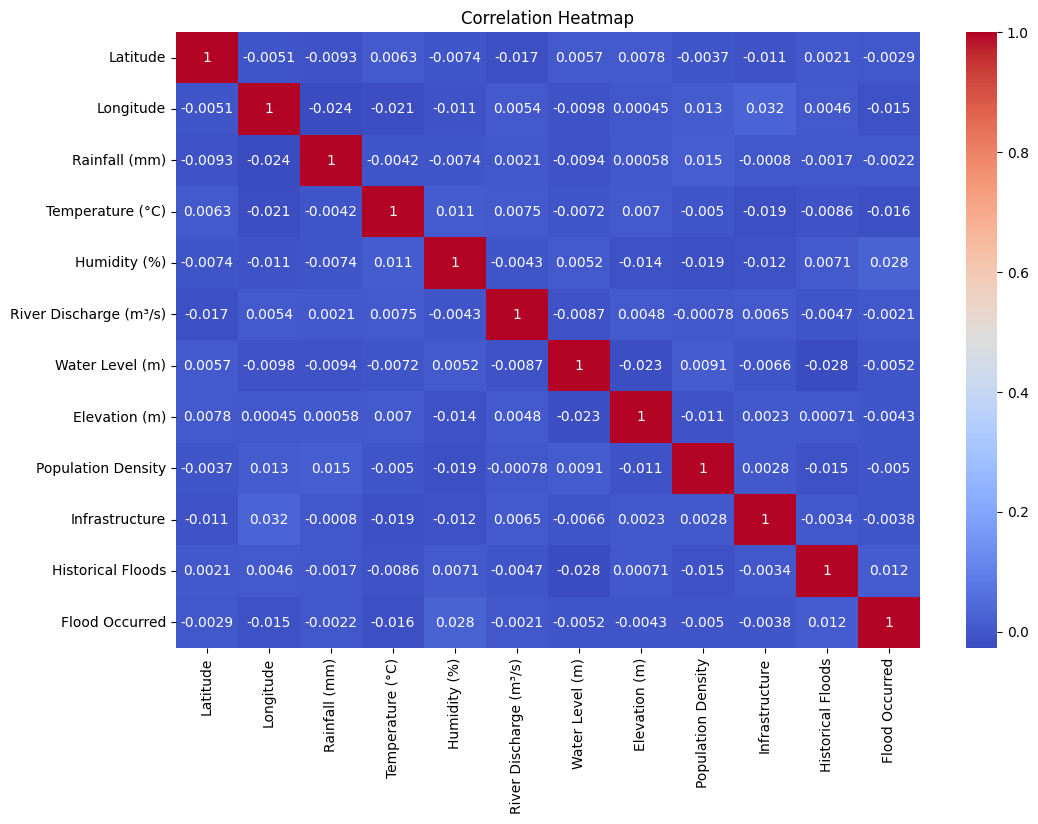


Categorical feature distributions::



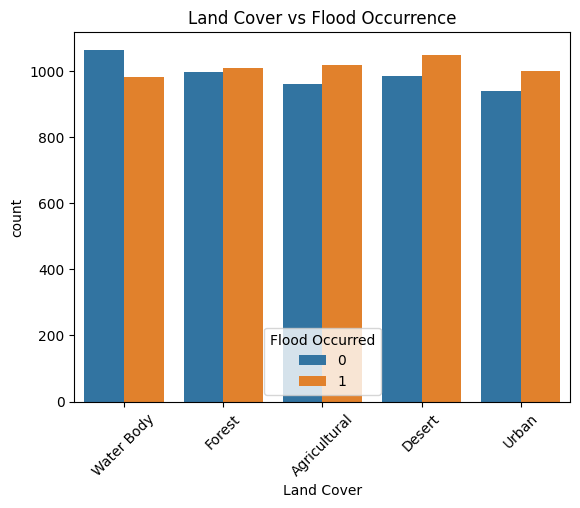

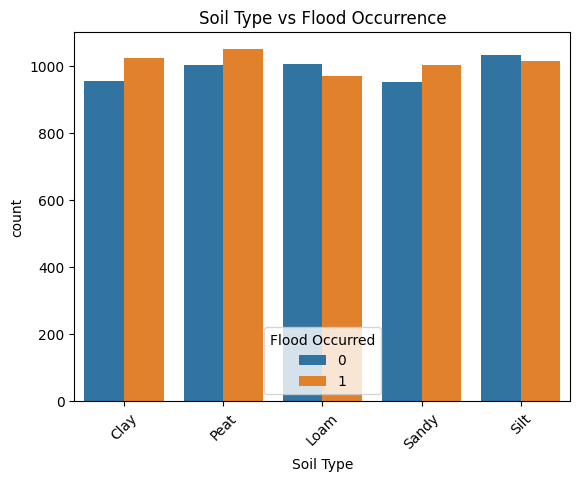

In [9]:
#Exploratory Data Analysis (EDA)

# Flood Occurrence distribution
print("\nFlood Occurrence distribution::\n")
print(data['Flood Occurred'].value_counts(normalize=True))


# Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of numerical features
print("\nHistogram of numerical features::\n")
data.hist(figsize=(15,10))
plt.show()

# Correlation heatmap
# Drop non-numeric columns before calculating correlation
numerical_data = data.drop(['Land Cover', 'Soil Type'], axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Categorical feature distributions
print("\nCategorical feature distributions::\n")
for col in ['Land Cover','Soil Type']:
    sns.countplot(x=col, hue='Flood Occurred', data=data)
    plt.title(f"{col} vs Flood Occurrence")
    plt.xticks(rotation=45)
    plt.show()

In [10]:
#Data Transformation

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical variables
le1 = LabelEncoder()
le2 = LabelEncoder()

data['Land Cover'] = le1.fit_transform(data['Land Cover'])
data['Soil Type'] = le2.fit_transform(data['Soil Type'])

# Scale numerical features
num_cols = ['Rainfall (mm)','Temperature (°C)','Humidity (%)',
            'River Discharge (m³/s)','Water Level (m)','Elevation (m)',
            'Population Density']

scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

data.head()


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,0.801884,0.482494,-0.684316,1.193409,0.833556,-1.596634,4,0,0.782416,1,0,1
1,35.570715,77.654451,-1.100359,-0.136414,-1.389866,-0.029923,1.318694,1.151515,2,2,0.650929,0,1,0
2,29.227824,73.108463,-0.534981,1.611824,-1.280827,-1.067119,-0.134223,-0.873977,0,1,-0.228955,1,1,1
3,25.361096,85.610733,0.569224,-0.968007,-1.093072,0.809835,-0.739142,-0.752874,1,3,0.396053,1,1,0
4,12.524541,81.822101,-0.062635,0.308475,-1.013623,-0.292954,-0.636001,-0.954627,0,1,0.397751,1,0,0


Flood Occurred            1.000000
Humidity (%)              0.027754
Historical Floods         0.012030
River Discharge (m³/s)   -0.002115
Rainfall (mm)            -0.002170
Latitude                 -0.002908
Infrastructure           -0.003846
Elevation (m)            -0.004331
Population Density       -0.005007
Water Level (m)          -0.005211
Soil Type                -0.006313
Longitude                -0.015008
Temperature (°C)         -0.015771
Land Cover               -0.019871
Name: Flood Occurred, dtype: float64


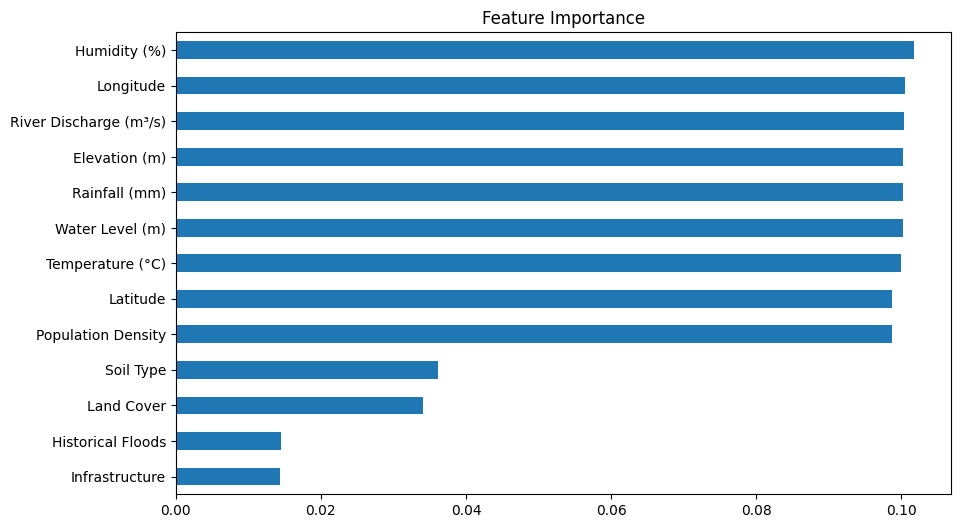

In [11]:
# Feature Selection

# Correlation with target
corr = data.corr()['Flood Occurred'].sort_values(ascending=False)
print(corr)

# Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

X = data.drop('Flood Occurred', axis=1)
y = data['Flood Occurred']

model = RandomForestClassifier(random_state=42)
model.fit(X,y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6), title="Feature Importance")
plt.show()
